In [2]:
# 02 - LIMPIEZA Y PROCESAMIENTO DE DATOS
# Objetivo: Cargar, limpiar y preparar datos para análisis

# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas")
print(f"📅 Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Bibliotecas importadas
📅 Fecha: 2026-02-17 10:55:26


In [3]:
# Cargar todos los archivos CSV
print("📂 Cargando datos de data/raw/...\n")

data_files = {
    'fertility': None,
    'gdp': None,
    'unemployment': None,
    'education': None,
    'labor_force': None,
    'urbanization': None
}

# Buscar y cargar archivos
raw_path = '../data/raw/'
for filename in os.listdir(raw_path):
    if filename.endswith('.csv'):
        if 'fertility' in filename:
            data_files['fertility'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Fertilidad: {data_files['fertility'].shape}")
        elif 'gdp' in filename:
            data_files['gdp'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ PIB: {data_files['gdp'].shape}")
        elif 'unemployment' in filename:
            data_files['unemployment'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Desempleo: {data_files['unemployment'].shape}")
        elif 'education' in filename:
            data_files['education'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Educación: {data_files['education'].shape}")
        elif 'labor' in filename:
            data_files['labor_force'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Fuerza laboral: {data_files['labor_force'].shape}")
        elif 'urbanization' in filename:
            data_files['urbanization'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Urbanización: {data_files['urbanization'].shape}")

print(f"\n🎉 {sum(1 for v in data_files.values() if v is not None)}/6 datasets cargados exitosamente")

📂 Cargando datos de data/raw/...

✅ Educación: (266, 24)
✅ Fuerza laboral: (266, 24)
✅ Fertilidad: (266, 24)
✅ PIB: (266, 24)
✅ Desempleo: (266, 24)
✅ Urbanización: (266, 24)

🎉 6/6 datasets cargados exitosamente


In [4]:
# Analizar valores faltantes en cada dataset
print("🔍 ANÁLISIS DE VALORES FALTANTES\n")
print("="*60)

for name, df in data_files.items():
    if df is not None:
        total_values = df.size
        missing_values = df.isna().sum().sum()
        missing_pct = (missing_values / total_values) * 100
        
        print(f"\n📊 {name.upper()}")
        print(f"   Dimensiones: {df.shape[0]} países × {df.shape[1]} años")
        print(f"   Valores faltantes: {missing_values:,} de {total_values:,} ({missing_pct:.1f}%)")
        
        # Mostrar los primeros 3 países
        print(f"   Primeros 3 países: {df.index[0]}, {df.index[1]}, {df.index[2]}")

print("\n" + "="*60)
print("✅ Análisis completado")

🔍 ANÁLISIS DE VALORES FALTANTES


📊 FERTILITY
   Dimensiones: 266 países × 24 años
   Valores faltantes: 24 de 6,384 (0.4%)
   Primeros 3 países: ABW, AFE, AFG

📊 GDP
   Dimensiones: 266 países × 24 años
   Valores faltantes: 191 de 6,384 (3.0%)
   Primeros 3 países: ABW, AFE, AFG

📊 UNEMPLOYMENT
   Dimensiones: 266 países × 24 años
   Valores faltantes: 748 de 6,384 (11.7%)
   Primeros 3 países: ABW, AFE, AFG

📊 EDUCATION
   Dimensiones: 266 países × 24 años
   Valores faltantes: 1,856 de 6,384 (29.1%)
   Primeros 3 países: ABW, AFE, AFG

📊 LABOR_FORCE
   Dimensiones: 266 países × 24 años
   Valores faltantes: 748 de 6,384 (11.7%)
   Primeros 3 países: ABW, AFE, AFG

📊 URBANIZATION
   Dimensiones: 266 países × 24 años
   Valores faltantes: 24 de 6,384 (0.4%)
   Primeros 3 países: ABW, AFE, AFG

✅ Análisis completado


In [5]:
# Ver ejemplo de datos de FERTILIDAD
print("🔍 EJEMPLO DE DATOS - FERTILIDAD\n")
print(data_files['fertility'].head(10))
print(f"\nPaíses totales: {len(data_files['fertility'])}")

🔍 EJEMPLO DE DATOS - FERTILIDAD

             2000      2001      2002      2003      2004      2005      2006  \
economy                                                                         
ABW      1.845000  1.813000  1.800000  1.808000  1.819000  1.844000  1.862000   
AFE      5.549893  5.501766  5.449696  5.407328  5.381308  5.350399  5.305920   
AFG      7.566000  7.453000  7.320000  7.174000  7.018000  6.858000  6.686000   
AFW      6.022143  5.990074  5.956202  5.923573  5.895514  5.871770  5.846028   
AGO      6.639000  6.601000  6.567000  6.533000  6.499000  6.461000  6.419000   
ALB      2.217000  2.141000  2.002000  2.006000  1.889000  1.787000  1.686000   
AND      1.273000  1.305000  1.265000  1.180000  1.229000  1.224000  1.234000   
ARB      3.934749  3.858450  3.781001  3.727254  3.679651  3.643336  3.619228   
ARE      2.733000  2.622000  2.541000  2.491000  2.385000  2.232000  1.958000   
ARG      2.591000  2.531000  2.493000  2.451000  2.430000  2.426000  2.40000

In [7]:
# LIMPIEZA Y CREACIÓN DE DATASET MAESTRO
print("🧹 Limpiando datos y creando dataset maestro...\n")

# Convertir todo a formato long (país, año, valor)
dfs_long = []

for name, df in data_files.items():
    if df is not None:
        # Resetear índice para tener país como columna
        df_long = df.reset_index()
        df_long = df_long.melt(id_vars='economy', var_name='year', value_name=name)
        dfs_long.append(df_long)

# Combinar todos los datasets
master = dfs_long[0]
for df in dfs_long[1:]:
    master = master.merge(df, on=['economy', 'year'], how='outer')

# Convertir año a numérico
master['year'] = pd.to_numeric(master['year'])

# Renombrar columna economy a country
master = master.rename(columns={'economy': 'country'})

print(f"✅ Dataset maestro creado")
print(f"   Dimensiones: {master.shape[0]} filas × {master.shape[1]} columnas")
print(f"   Países únicos: {master['country'].nunique()}")
print(f"   Años: {master['year'].min()} - {master['year'].max()}")
print(f"\n📊 Columnas: {list(master.columns)}")
print(f"\n🔍 Primeras filas:")
master.head()

🧹 Limpiando datos y creando dataset maestro...

✅ Dataset maestro creado
   Dimensiones: 6384 filas × 8 columnas
   Países únicos: 266
   Años: 2000 - 2023

📊 Columnas: ['country', 'year', 'fertility', 'gdp', 'unemployment', 'education', 'labor_force', 'urbanization']

🔍 Primeras filas:


,country,year,fertility,gdp,unemployment,education,labor_force,urbanization
0,ABW,2000,1.845,20681.023027,NaN,NaN,NaN,65.354550
1,ABW,2001,1.813,20740.132583,NaN,98.647430,NaN,65.335114
2,ABW,2002,1.800,21307.248251,NaN,102.293442,NaN,65.282069
3,ABW,2003,1.808,21949.485996,NaN,104.977783,NaN,65.198292
4,ABW,2004,1.819,23700.631990,NaN,101.585007,NaN,65.088653


📈 Creando gráfico de tendencia global...



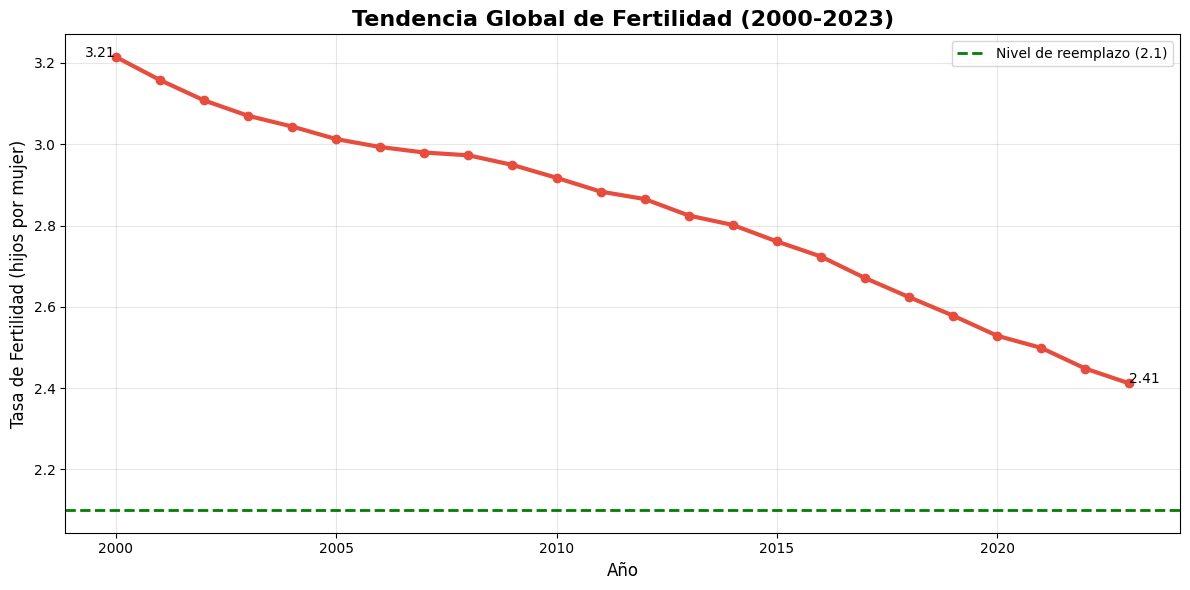

📊 Fertilidad promedio mundial:
   2000: 3.21 hijos por mujer
   2023: 2.41 hijos por mujer
   Cambio: -0.80 (-25.0%)


In [9]:
# VISUALIZACIÓN 1: Tendencia global de fertilidad
print("📈 Creando gráfico de tendencia global...\n")

# Calcular promedio mundial por año
global_trend = master.groupby('year')['fertility'].mean()

# Crear gráfico
plt.figure(figsize=(12, 6))
plt.plot(global_trend.index, global_trend.values, linewidth=3, color='#e74c3c', marker='o')
plt.title('Tendencia Global de Fertilidad (2000-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Fertilidad (hijos por mujer)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=2.1, color='green', linestyle='--', linewidth=2, label='Nivel de reemplazo (2.1)')
plt.legend(fontsize=10)

# Añadir valores en puntos clave
plt.text(2000, global_trend[2000], f'{global_trend[2000]:.2f}', fontsize=10, ha='right')
plt.text(2023, global_trend[2023], f'{global_trend[2023]:.2f}', fontsize=10, ha='left')

plt.tight_layout()
plt.show()

print(f"📊 Fertilidad promedio mundial:")
print(f"   2000: {global_trend[2000]:.2f} hijos por mujer")
print(f"   2023: {global_trend[2023]:.2f} hijos por mujer")
print(f"   Cambio: {global_trend[2023] - global_trend[2000]:.2f} ({(global_trend[2023] - global_trend[2000])/global_trend[2000]*100:.1f}%)")

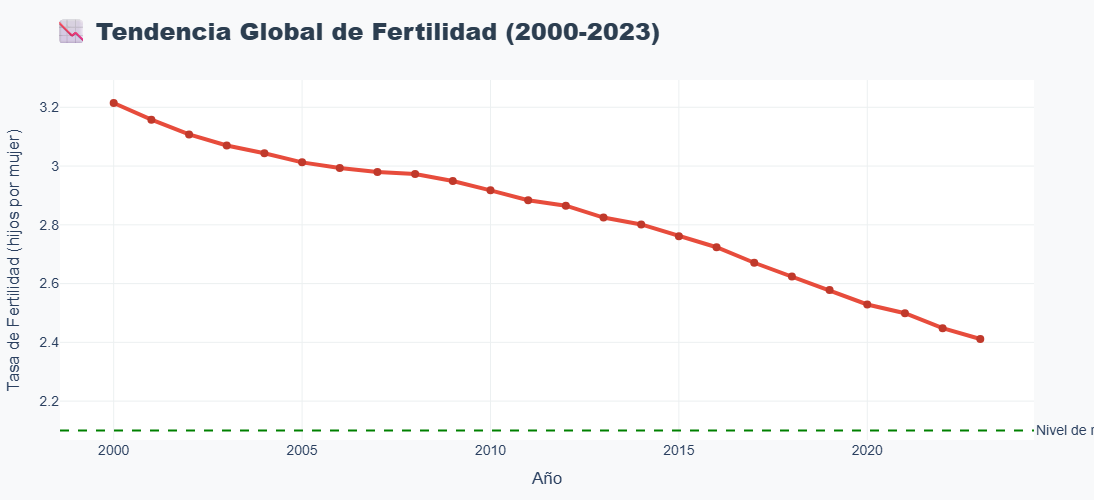


📊 INSIGHT CLAVE:
   La fertilidad global cayó de 3.21 a 2.41
   Esto es una caída del 25.0% en 23 años
   ¡Estamos -0.31 puntos por DEBAJO del nivel de reemplazo!


In [11]:
# VISUALIZACIÓN MEJORADA - Tendencia global PROFESIONAL
import plotly.graph_objects as go

# Calcular tendencia
global_trend = master.groupby('year')['fertility'].mean()

# Crear gráfico interactivo con Plotly
fig = go.Figure()

# Línea principal
fig.add_trace(go.Scatter(
    x=global_trend.index,
    y=global_trend.values,
    mode='lines+markers',
    name='Fertilidad Global',
    line=dict(color='#e74c3c', width=4),
    marker=dict(size=8, color='#c0392b'),
    hovertemplate='<b>%{x}</b><br>Fertilidad: %{y:.2f}<extra></extra>'
))

# Línea de reemplazo
fig.add_hline(
    y=2.1, 
    line_dash="dash", 
    line_color="green",
    annotation_text="Nivel de reemplazo (2.1)",
    annotation_position="right"
)

# Diseño profesional
fig.update_layout(
    title={
        'text': '📉 Tendencia Global de Fertilidad (2000-2023)',
        'font': {'size': 24, 'color': '#2c3e50', 'family': 'Arial Black'}
    },
    xaxis_title='Año',
    yaxis_title='Tasa de Fertilidad (hijos por mujer)',
    font=dict(size=14, family='Arial'),
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='#f8f9fa',
    height=500,
    margin=dict(l=60, r=60, t=80, b=60)
)

# Grid sutil
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')

fig.show()

# Stats
cambio_absoluto = global_trend[2023] - global_trend[2000]
cambio_porcentual = (cambio_absoluto / global_trend[2000]) * 100

print(f"\n📊 INSIGHT CLAVE:")
print(f"   La fertilidad global cayó de {global_trend[2000]:.2f} a {global_trend[2023]:.2f}")
print(f"   Esto es una caída del {abs(cambio_porcentual):.1f}% en 23 años")
print(f"   ¡Estamos {2.1 - global_trend[2023]:.2f} puntos por DEBAJO del nivel de reemplazo!")

🇭🇺 Analizando el caso de Hungría...



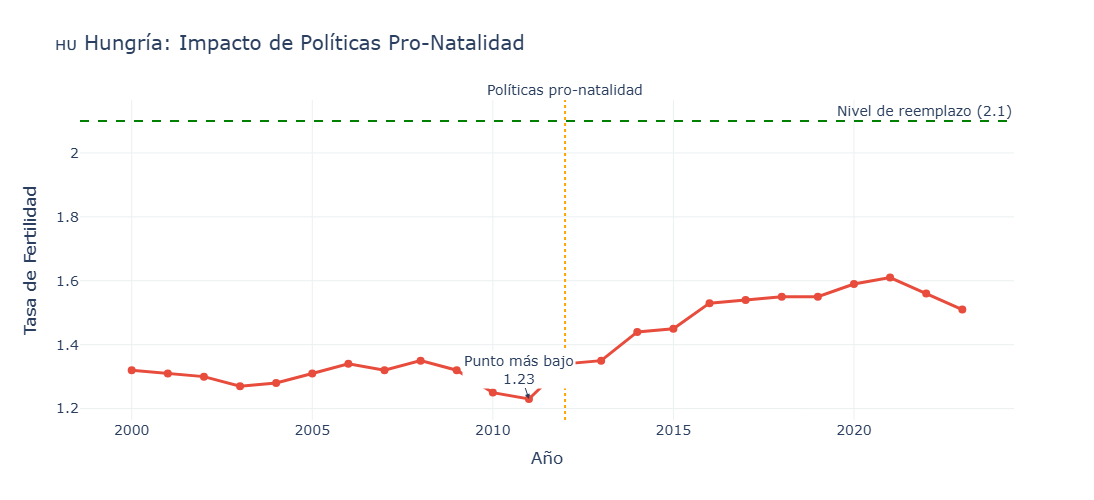

📉 Punto más bajo: 1.23 en 2011
📈 Valor en 2023: 1.51
🔄 Recuperación desde el mínimo: 0.28 puntos
⚠️  Pero aún 0.59 puntos por debajo del reemplazo


In [12]:
# VISUALIZACIÓN: Caso Hungría - Políticas pro-natalidad
print("🇭🇺 Analizando el caso de Hungría...\n")

# Filtrar datos de Hungría
hungary = master[master['country'] == 'HUN'].sort_values('year')

# Crear gráfico interactivo
fig = go.Figure()

# Línea de fertilidad
fig.add_trace(go.Scatter(
    x=hungary['year'],
    y=hungary['fertility'],
    mode='lines+markers',
    name='Hungría',
    line=dict(color='#e74c3c', width=3),
    marker=dict(size=8),
    hovertemplate='<b>%{x}</b><br>Fertilidad: %{y:.2f}<extra></extra>'
))

# Nivel de reemplazo
fig.add_hline(y=2.1, line_dash="dash", line_color="green", 
              annotation_text="Nivel de reemplazo (2.1)")

# Marcar el punto de cambio de política (2012)
fig.add_vline(x=2012, line_dash="dot", line_color="orange",
              annotation_text="Políticas pro-natalidad", 
              annotation_position="top")

# Añadir anotaciones
fig.add_annotation(x=2011, y=1.23, text="Punto más bajo<br>1.23",
                   showarrow=True, arrowhead=2, bgcolor="white")

fig.update_layout(
    title='🇭🇺 Hungría: Impacto de Políticas Pro-Natalidad',
    xaxis_title='Año',
    yaxis_title='Tasa de Fertilidad',
    font=dict(size=14),
    hovermode='x unified',
    plot_bgcolor='white',
    height=500
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')

fig.show()

# Análisis
min_year = hungary[hungary['fertility'] == hungary['fertility'].min()]['year'].values[0]
min_val = hungary['fertility'].min()
val_2023 = hungary[hungary['year'] == 2023]['fertility'].values[0]

print(f"📉 Punto más bajo: {min_val:.2f} en {min_year}")
print(f"📈 Valor en 2023: {val_2023:.2f}")
print(f"🔄 Recuperación desde el mínimo: {val_2023 - min_val:.2f} puntos")
print(f"⚠️  Pero aún {2.1 - val_2023:.2f} puntos por debajo del reemplazo")

💰 Analizando relación entre PIB y Fertilidad...



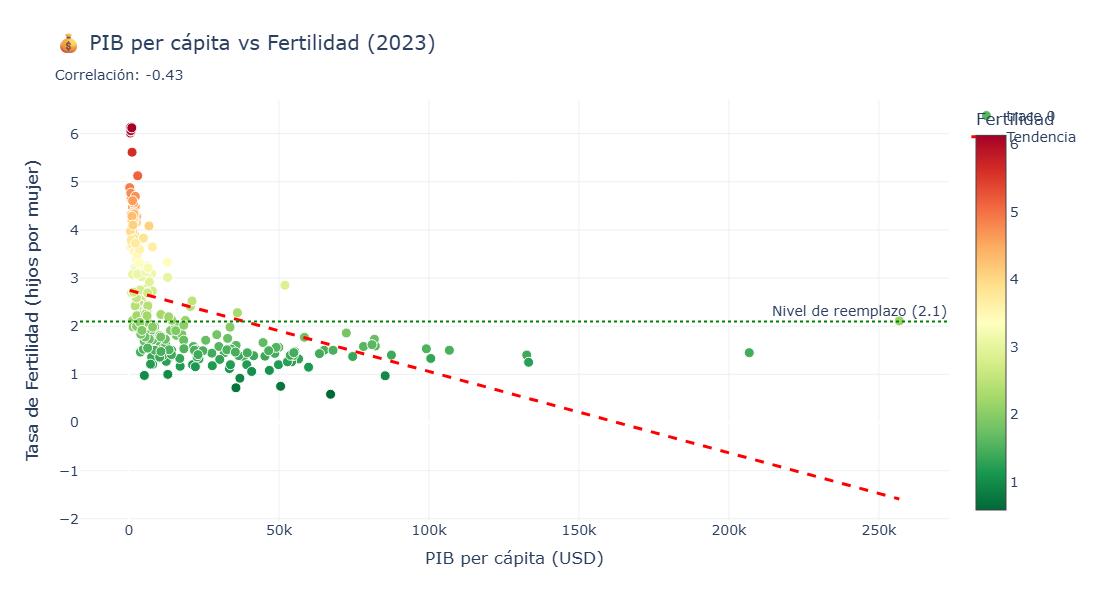

📊 CORRELACIÓN: -0.433
   ✅ Correlación NEGATIVA MODERADA

💎 TOP 5 PAÍSES MÁS RICOS:
   MCO: $256,800 → 2.11 hijos
   LIE: $206,781 → 1.45 hijos
   LUX: $133,231 → 1.25 hijos
   BMU: $132,604 → 1.40 hijos
   IRL: $106,819 → 1.50 hijos

👶 TOP 5 MAYOR FERTILIDAD:
   SOM: 6.13 hijos → $597
   TCD: 6.12 hijos → $949
   NER: 6.06 hijos → $638
   COD: 6.05 hijos → $660
   CAF: 6.01 hijos → $496


In [13]:
# VISUALIZACIÓN: ¿Países ricos tienen menos hijos?
print("💰 Analizando relación entre PIB y Fertilidad...\n")

# Filtrar datos de 2023 (más recientes) y eliminar NaN
data_2023 = master[master['year'] == 2023].dropna(subset=['gdp', 'fertility'])

# Calcular correlación
correlation = data_2023['gdp'].corr(data_2023['fertility'])

# Crear scatter plot interactivo
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data_2023['gdp'],
    y=data_2023['fertility'],
    mode='markers',
    marker=dict(
        size=10,
        color=data_2023['fertility'],
        colorscale='RdYlGn_r',  # Rojo = bajo, Verde = alto
        showscale=True,
        colorbar=dict(title="Fertilidad"),
        line=dict(width=1, color='white')
    ),
    text=data_2023['country'],
    hovertemplate='<b>%{text}</b><br>PIB: $%{x:,.0f}<br>Fertilidad: %{y:.2f}<extra></extra>'
))

# Línea de tendencia
z = np.polyfit(data_2023['gdp'], data_2023['fertility'], 1)
p = np.poly1d(z)
x_trend = np.linspace(data_2023['gdp'].min(), data_2023['gdp'].max(), 100)
fig.add_trace(go.Scatter(
    x=x_trend,
    y=p(x_trend),
    mode='lines',
    name='Tendencia',
    line=dict(color='red', width=3, dash='dash')
))

# Línea de nivel de reemplazo
fig.add_hline(y=2.1, line_dash="dot", line_color="green",
              annotation_text="Nivel de reemplazo (2.1)")

fig.update_layout(
    title=f'💰 PIB per cápita vs Fertilidad (2023)<br><sub>Correlación: {correlation:.2f}</sub>',
    xaxis_title='PIB per cápita (USD)',
    yaxis_title='Tasa de Fertilidad (hijos por mujer)',
    font=dict(size=14),
    hovermode='closest',
    plot_bgcolor='white',
    height=600
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')

fig.show()

# Análisis detallado
print(f"📊 CORRELACIÓN: {correlation:.3f}")
if correlation < -0.5:
    print(f"   ✅ Correlación NEGATIVA FUERTE")
    print(f"   💡 A mayor riqueza → menor fertilidad")
elif correlation < -0.3:
    print(f"   ✅ Correlación NEGATIVA MODERADA")
else:
    print(f"   ⚠️  Correlación DÉBIL")

# Top 5 países más ricos
top_rich = data_2023.nlargest(5, 'gdp')[['country', 'gdp', 'fertility']]
print(f"\n💎 TOP 5 PAÍSES MÁS RICOS:")
for idx, row in top_rich.iterrows():
    print(f"   {row['country']}: ${row['gdp']:,.0f} → {row['fertility']:.2f} hijos")

# Top 5 fertilidad más alta
top_fert = data_2023.nlargest(5, 'fertility')[['country', 'gdp', 'fertility']]
print(f"\n👶 TOP 5 MAYOR FERTILIDAD:")
for idx, row in top_fert.iterrows():
    print(f"   {row['country']}: {row['fertility']:.2f} hijos → ${row['gdp']:,.0f}")

🗺️ Creando mapa mundial interactivo...



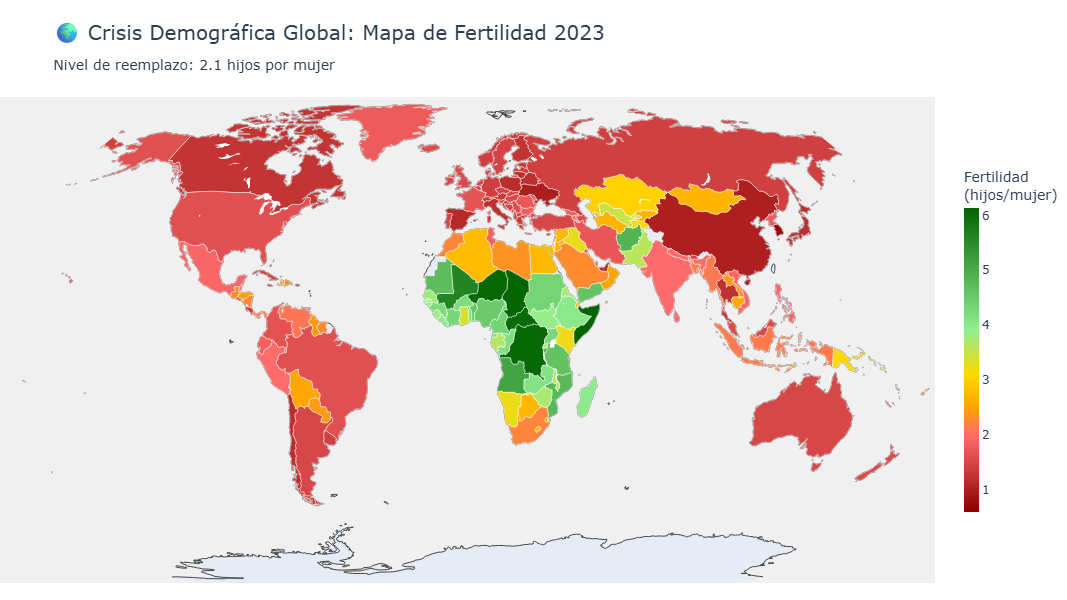

📊 RESUMEN MUNDIAL:

🔴 Crisis severa (<1.5): 68 países (25.7%)
🔵 Muy alta fertilidad (>4.0): 35 países (13.2%)
🟠 Por debajo de reemplazo (1.5-2.1): 74 países (27.9%)
🟡 Zona saludable (2.1-2.5): 25 países (9.4%)
🟢 Alta fertilidad (2.5-4.0): 63 países (23.8%)

🚨 INSIGHT CRÍTICO:
   142 de 265 países (53.6%)
   están por DEBAJO del nivel de reemplazo


In [14]:
# VISUALIZACIÓN: Mapa Mundial de Fertilidad
print("🗺️ Creando mapa mundial interactivo...\n")

# Preparar datos de 2023
map_data = master[master['year'] == 2023][['country', 'fertility']].dropna()

# Crear categorías por color
def categorize_fertility(rate):
    if rate < 1.5:
        return '🔴 Crisis severa (<1.5)'
    elif rate < 2.1:
        return '🟠 Por debajo de reemplazo (1.5-2.1)'
    elif rate < 2.5:
        return '🟡 Zona saludable (2.1-2.5)'
    elif rate < 4.0:
        return '🟢 Alta fertilidad (2.5-4.0)'
    else:
        return '🔵 Muy alta fertilidad (>4.0)'

map_data['category'] = map_data['fertility'].apply(categorize_fertility)

# Crear mapa coroplético interactivo
fig = go.Figure(data=go.Choropleth(
    locations=map_data['country'],
    z=map_data['fertility'],
    locationmode='ISO-3',
    colorscale=[
        [0, '#8B0000'],      # Rojo oscuro - Crisis
        [0.25, '#FF6B6B'],   # Rojo claro
        [0.35, '#FFA500'],   # Naranja - Bajo reemplazo
        [0.45, '#FFD700'],   # Amarillo - Zona saludable
        [0.6, '#90EE90'],    # Verde claro - Alta
        [1, '#006400']       # Verde oscuro - Muy alta
    ],
    colorbar=dict(
        title="Fertilidad<br>(hijos/mujer)",
        thickness=15,
        len=0.7
    ),
    text=map_data['country'],
    hovertemplate='<b>%{text}</b><br>Fertilidad: %{z:.2f}<extra></extra>',
    marker_line_color='white',
    marker_line_width=0.5
))

fig.update_layout(
    title={
        'text': '🌍 Crisis Demográfica Global: Mapa de Fertilidad 2023<br><sub>Nivel de reemplazo: 2.1 hijos por mujer</sub>',
        'font': {'size': 20, 'color': '#2c3e50'}
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='#f0f0f0'
    ),
    height=600,
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.show()

# Estadísticas por categoría
print("📊 RESUMEN MUNDIAL:\n")
category_counts = map_data['category'].value_counts().sort_index()
for cat, count in category_counts.items():
    pct = (count / len(map_data)) * 100
    print(f"{cat}: {count} países ({pct:.1f}%)")

# Insight clave
crisis_countries = len(map_data[map_data['fertility'] < 2.1])
total_countries = len(map_data)
print(f"\n🚨 INSIGHT CRÍTICO:")
print(f"   {crisis_countries} de {total_countries} países ({crisis_countries/total_countries*100:.1f}%)")
print(f"   están por DEBAJO del nivel de reemplazo")

🌍 Análisis por Continentes/Regiones



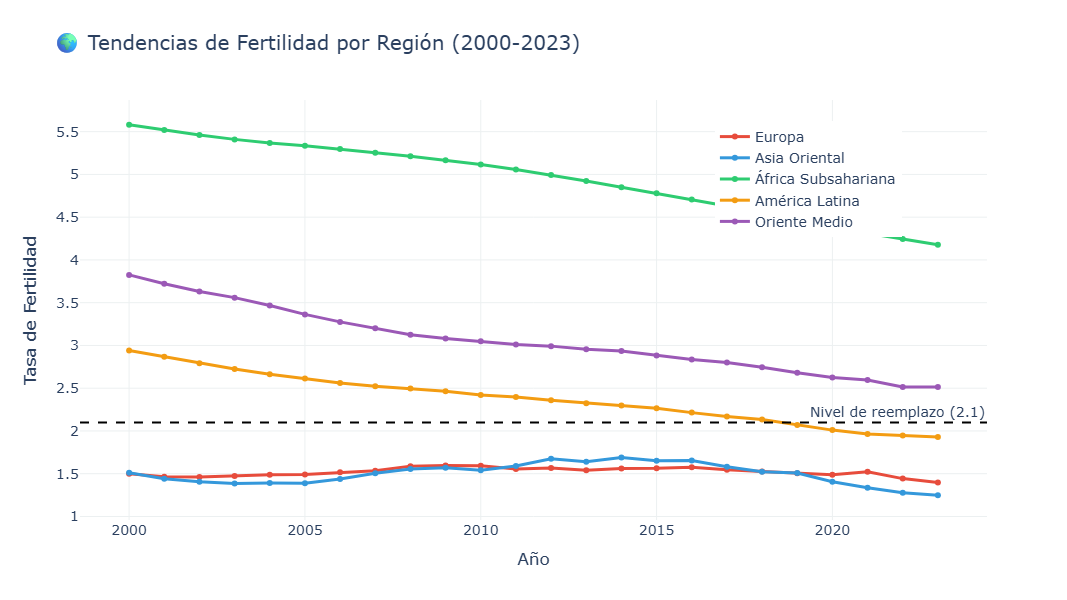


📊 FERTILIDAD POR REGIÓN (2023):

🟢 África Subsahariana: 4.18
🟢 Oriente Medio: 2.51
🟠 América Latina: 1.93
🔴 Europa: 1.40
🔴 Asia Oriental: 1.25

📉 CAMBIO 2000-2023:

Europa:
   2000: 1.50 → 2023: 1.40
   Cambio: -0.10 (-6.7%)

Asia Oriental:
   2000: 1.51 → 2023: 1.25
   Cambio: -0.26 (-17.4%)

África Subsahariana:
   2000: 5.58 → 2023: 4.18
   Cambio: -1.40 (-25.2%)

América Latina:
   2000: 2.94 → 2023: 1.93
   Cambio: -1.01 (-34.4%)

Oriente Medio:
   2000: 3.83 → 2023: 2.51
   Cambio: -1.31 (-34.3%)



In [15]:
# ANÁLISIS POR REGIONES
print("🌍 Análisis por Continentes/Regiones\n")

# Crear diccionario de regiones (códigos ISO3 de países)
regiones = {
    'Europa': ['ALB', 'AND', 'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 
               'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 'LVA', 'LTU',
               'LUX', 'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'ESP',
               'SWE', 'CHE', 'GBR', 'UKR', 'BLR', 'MDA', 'RUS', 'SRB', 'MKD', 'BIH'],
    
    'Asia Oriental': ['CHN', 'JPN', 'KOR', 'PRK', 'MNG', 'TWN', 'HKG', 'MAC'],
    
    'África Subsahariana': ['NGA', 'ETH', 'COD', 'TZA', 'KEN', 'UGA', 'SDN', 'DZA',
                           'MAR', 'AGO', 'GHA', 'MOZ', 'MDG', 'CMR', 'CIV', 'NER',
                           'BFA', 'MLI', 'MWI', 'ZMB', 'SOM', 'SEN', 'TCD', 'ZWE',
                           'GIN', 'RWA', 'BEN', 'TUN', 'BDI', 'SSD', 'TGO', 'SLE',
                           'LBY', 'LBR', 'MRT', 'CAF', 'ERI', 'GAM', 'BWA', 'NAM'],
    
    'América Latina': ['BRA', 'MEX', 'COL', 'ARG', 'PER', 'VEN', 'CHL', 'ECU', 'GTM',
                      'CUB', 'BOL', 'HTI', 'DOM', 'HND', 'PRY', 'NIC', 'SLV', 'CRI',
                      'PAN', 'URY', 'JAM', 'TTO', 'GUY', 'SUR', 'BLZ'],
    
    'Oriente Medio': ['SAU', 'YEM', 'IRQ', 'SYR', 'JOR', 'ARE', 'ISR', 'LBN', 'PSE',
                     'OMN', 'KWT', 'QAT', 'BHR']
}

# Asignar región a cada país
def get_region(country_code):
    for region, countries in regiones.items():
        if country_code in countries:
            return region
    return 'Otro'

master['region'] = master['country'].apply(get_region)

# Calcular promedio por región y año
regional_trend = master.groupby(['region', 'year'])['fertility'].mean().reset_index()

# Crear gráfico comparativo
fig = go.Figure()

colors = {
    'Europa': '#e74c3c',
    'Asia Oriental': '#3498db',
    'África Subsahariana': '#2ecc71',
    'América Latina': '#f39c12',
    'Oriente Medio': '#9b59b6'
}

for region in ['Europa', 'Asia Oriental', 'África Subsahariana', 'América Latina', 'Oriente Medio']:
    data = regional_trend[regional_trend['region'] == region]
    
    fig.add_trace(go.Scatter(
        x=data['year'],
        y=data['fertility'],
        mode='lines+markers',
        name=region,
        line=dict(width=3, color=colors[region]),
        marker=dict(size=6),
        hovertemplate='<b>' + region + '</b><br>%{x}<br>Fertilidad: %{y:.2f}<extra></extra>'
    ))

# Línea de reemplazo
fig.add_hline(y=2.1, line_dash="dash", line_color="black", 
              annotation_text="Nivel de reemplazo (2.1)")

fig.update_layout(
    title='🌍 Tendencias de Fertilidad por Región (2000-2023)',
    xaxis_title='Año',
    yaxis_title='Tasa de Fertilidad',
    font=dict(size=14),
    hovermode='x unified',
    plot_bgcolor='white',
    height=600,
    legend=dict(x=0.7, y=0.95)
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')

fig.show()

# Estadísticas 2023
print("\n📊 FERTILIDAD POR REGIÓN (2023):\n")
regional_2023 = master[master['year'] == 2023].groupby('region')['fertility'].mean().sort_values(ascending=False)

for region, fert in regional_2023.items():
    if region != 'Otro':
        status = "🔴" if fert < 1.5 else "🟠" if fert < 2.1 else "🟢"
        print(f"{status} {region}: {fert:.2f}")

# Cambio 2000 vs 2023
print("\n📉 CAMBIO 2000-2023:\n")
for region in ['Europa', 'Asia Oriental', 'África Subsahariana', 'América Latina', 'Oriente Medio']:
    data = regional_trend[regional_trend['region'] == region]
    val_2000 = data[data['year'] == 2000]['fertility'].values[0]
    val_2023 = data[data['year'] == 2023]['fertility'].values[0]
    cambio = val_2023 - val_2000
    cambio_pct = (cambio / val_2000) * 100
    
    print(f"{region}:")
    print(f"   2000: {val_2000:.2f} → 2023: {val_2023:.2f}")
    print(f"   Cambio: {cambio:.2f} ({cambio_pct:.1f}%)\n")

In [16]:
# DESCARGAR MORTALIDAD INFANTIL + CORREGIR REGIONES
import wbgapi as wb
import time

print("📥 Descargando mortalidad infantil del Banco Mundial...\n")

try:
    # SP.DYN.IMRT.IN = Mortalidad infantil (por cada 1000 nacidos vivos)
    infant_mortality = wb.data.DataFrame(
        'SP.DYN.IMRT.IN',
        time=range(2000, 2024),
        labels=False,
        numericTimeKeys=True
    )
    
    print(f"✅ Descargado: {infant_mortality.shape[0]} países × {infant_mortality.shape[1]} años")
    
    # Guardar en raw
    infant_mortality.to_csv('../data/raw/worldbank_infant_mortality_20260210.csv')
    print(f"💾 Guardado en data/raw/")
    
except Exception as e:
    print(f"❌ Error: {e}")

# Convertir a formato long
im_long = infant_mortality.reset_index()
im_long = im_long.melt(
    id_vars='economy', 
    var_name='year', 
    value_name='infant_mortality'
)
im_long['year'] = pd.to_numeric(im_long['year'])
im_long = im_long.rename(columns={'economy': 'country'})

# Agregar al dataset maestro
master = master.merge(im_long, on=['country', 'year'], how='left')

print(f"\n✅ Mortalidad infantil agregada al dataset maestro")
print(f"   Columnas ahora: {list(master.columns)}")

📥 Descargando mortalidad infantil del Banco Mundial...

✅ Descargado: 266 países × 24 años
💾 Guardado en data/raw/

✅ Mortalidad infantil agregada al dataset maestro
   Columnas ahora: ['country', 'year', 'fertility', 'gdp', 'unemployment', 'education', 'labor_force', 'urbanization', 'region', 'infant_mortality']


🔬 Analizando relación Fertilidad vs Mortalidad Infantil en África



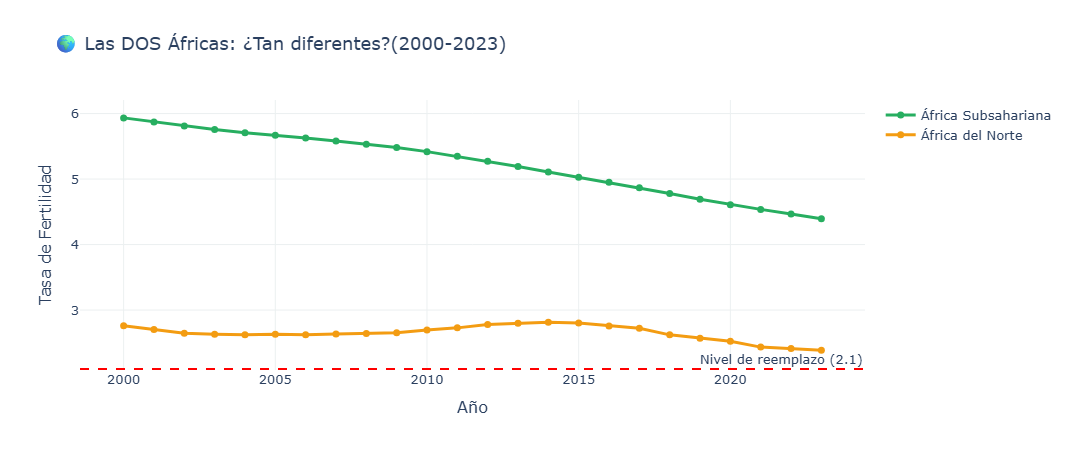

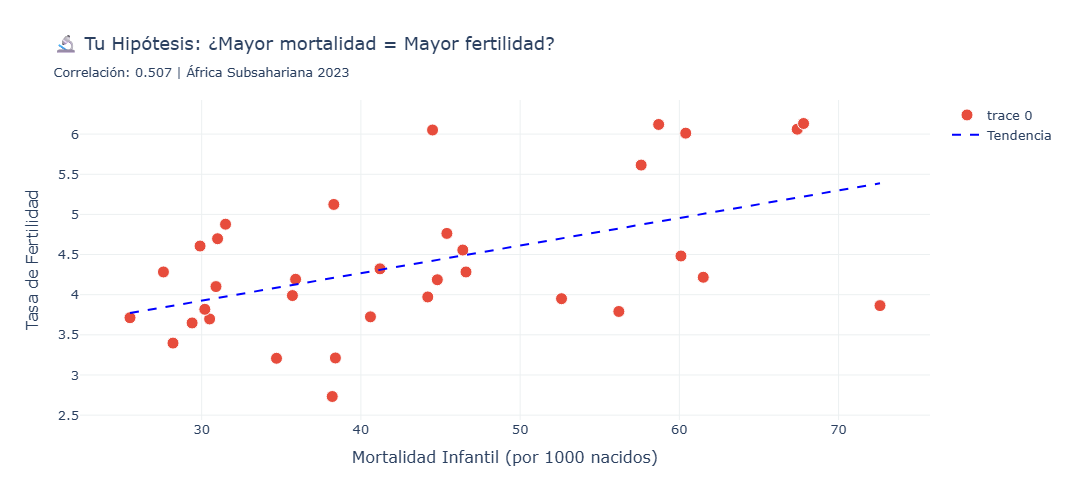

📊 RESULTADO DE TU HIPÓTESIS:
   Correlación Fertilidad-Mortalidad: 0.507
   ✅ HIPÓTESIS CONFIRMADA - Correlación POSITIVA FUERTE
   💡 A mayor mortalidad infantil → mayor fertilidad
   💡 La bajada en África puede ser por mejora en salud
      no necesariamente por elección de las mujeres


In [18]:
# ANÁLISIS: ¿La bajada de fertilidad en África es real?
print("🔬 Analizando relación Fertilidad vs Mortalidad Infantil en África\n")

# Agregar África del Norte como región
africa_norte = ['MAR', 'DZA', 'TUN', 'EGY', 'LBY', 'SDN']

def get_region_v2(country_code):
    regiones_v2 = {
        'Europa': ['ALB', 'AND', 'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 
                   'EST', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 
                   'LVA', 'LTU', 'LUX', 'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 
                   'SVK', 'SVN', 'ESP', 'SWE', 'CHE', 'GBR', 'UKR', 'BLR', 'MDA', 
                   'RUS', 'SRB', 'MKD', 'BIH'],
        'Asia Oriental': ['CHN', 'JPN', 'KOR', 'PRK', 'MNG', 'HKG', 'MAC'],
        'África Subsahariana': ['NGA', 'ETH', 'COD', 'TZA', 'KEN', 'UGA',
                               'AGO', 'GHA', 'MOZ', 'MDG', 'CMR', 'CIV', 'NER',
                               'BFA', 'MLI', 'MWI', 'ZMB', 'SOM', 'SEN', 'TCD', 
                               'ZWE', 'GIN', 'RWA', 'BEN', 'BDI', 'SSD', 'TGO', 
                               'SLE', 'LBR', 'MRT', 'CAF', 'ERI', 'BWA', 'NAM'],
        'África del Norte': ['MAR', 'DZA', 'TUN', 'EGY', 'LBY'],
        'América Latina': ['BRA', 'MEX', 'COL', 'ARG', 'PER', 'VEN', 'CHL', 'ECU', 
                          'GTM', 'CUB', 'BOL', 'HTI', 'DOM', 'HND', 'PRY', 'NIC', 
                          'SLV', 'CRI', 'PAN', 'URY', 'JAM', 'TTO', 'GUY', 'SUR'],
        'Oriente Medio': ['SAU', 'YEM', 'IRQ', 'SYR', 'JOR', 'ARE', 'ISR', 
                         'LBN', 'PSE', 'OMN', 'KWT', 'QAT', 'BHR']
    }
    for region, countries in regiones_v2.items():
        if country_code in countries:
            return region
    return 'Otro'

# Actualizar regiones
master['region'] = master['country'].apply(get_region_v2)

# ============================================
# GRÁFICO 1: Las DOS Áfricas comparadas
# ============================================
africa_data = master[
    master['region'].isin(['África Subsahariana', 'África del Norte'])
].groupby(['region', 'year'])['fertility'].mean().reset_index()

fig1 = go.Figure()

colors_africa = {
    'África Subsahariana': '#27ae60',
    'África del Norte': '#f39c12'
}

for region in ['África Subsahariana', 'África del Norte']:
    data = africa_data[africa_data['region'] == region]
    fig1.add_trace(go.Scatter(
        x=data['year'],
        y=data['fertility'],
        mode='lines+markers',
        name=region,
        line=dict(width=3, color=colors_africa[region]),
        marker=dict(size=7),
        hovertemplate='<b>' + region + '</b><br>%{x}<br>Fertilidad: %{y:.2f}<extra></extra>'
    ))

fig1.add_hline(y=2.1, line_dash="dash", line_color="red",
               annotation_text="Nivel de reemplazo (2.1)")

fig1.update_layout(
    title='🌍 Las DOS Áfricas: ¿Tan diferentes?(2000-2023)',
    xaxis_title='Año',
    yaxis_title='Tasa de Fertilidad',
    plot_bgcolor='white',
    height=450,
    font=dict(size=13),
    hovermode='x unified'
)
fig1.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig1.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig1.show()

# ============================================
# GRÁFICO 2: Fertilidad vs Mortalidad Infantil
# ============================================
africa_sub = master[
    (master['region'] == 'África Subsahariana') & 
    (master['year'] == 2023)
].dropna(subset=['fertility', 'infant_mortality'])

correlacion = africa_sub['fertility'].corr(africa_sub['infant_mortality'])

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=africa_sub['infant_mortality'],
    y=africa_sub['fertility'],
    mode='markers',
    marker=dict(
        size=12,
        color='#e74c3c',
        line=dict(width=1, color='white')
    ),
    text=africa_sub['country'],
    hovertemplate='<b>%{text}</b><br>Mortalidad: %{x:.1f}<br>Fertilidad: %{y:.2f}<extra></extra>'
))

# Línea de tendencia
z = np.polyfit(africa_sub['infant_mortality'], africa_sub['fertility'], 1)
p = np.poly1d(z)
x_range = np.linspace(africa_sub['infant_mortality'].min(), 
                      africa_sub['infant_mortality'].max(), 100)
fig2.add_trace(go.Scatter(
    x=x_range, y=p(x_range),
    mode='lines',
    name='Tendencia',
    line=dict(color='blue', width=2, dash='dash')
))

fig2.update_layout(
    title=f'🔬 Tu Hipótesis: ¿Mayor mortalidad = Mayor fertilidad?<br><sub>Correlación: {correlacion:.3f} | África Subsahariana 2023</sub>',
    xaxis_title='Mortalidad Infantil (por 1000 nacidos)',
    yaxis_title='Tasa de Fertilidad',
    plot_bgcolor='white',
    height=500,
    font=dict(size=13)
)
fig2.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig2.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig2.show()

# Resultado
print(f"📊 RESULTADO DE TU HIPÓTESIS:")
print(f"   Correlación Fertilidad-Mortalidad: {correlacion:.3f}")
if correlacion > 0.5:
    print(f"   ✅ HIPÓTESIS CONFIRMADA - Correlación POSITIVA FUERTE")
    print(f"   💡 A mayor mortalidad infantil → mayor fertilidad")
    print(f"   💡 La bajada en África puede ser por mejora en salud")
    print(f"      no necesariamente por elección de las mujeres")
elif correlacion > 0.3:
    print(f"   ⚠️  HIPÓTESIS PARCIALMENTE CONFIRMADA")
    print(f"   Correlación moderada - hay otros factores también")
else:
    print(f"   ❌ HIPÓTESIS NO CONFIRMADA")
    print(f"   La relación es más compleja")

🏆 RANKINGS DE FERTILIDAD (2023)



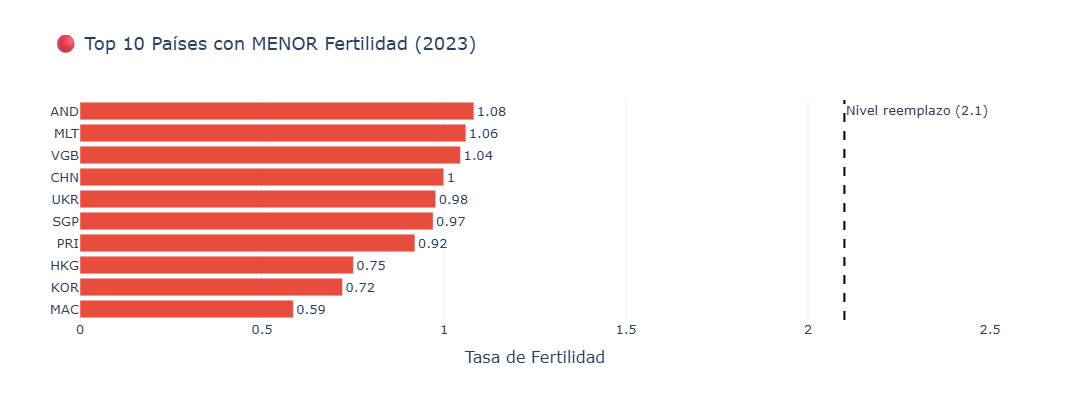

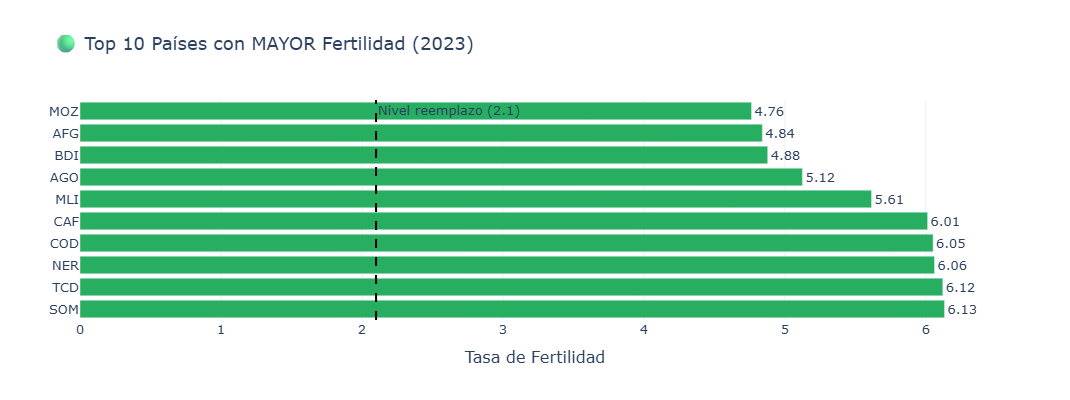

🔴 MENOR FERTILIDAD:
   MAC: 0.59
   KOR: 0.72
   HKG: 0.75
   PRI: 0.92
   SGP: 0.97
   UKR: 0.98
   CHN: 1.00
   VGB: 1.04
   MLT: 1.06
   AND: 1.08

🟢 MAYOR FERTILIDAD:
   SOM: 6.13
   TCD: 6.12
   NER: 6.06
   COD: 6.05
   CAF: 6.01
   MLI: 5.61
   AGO: 5.12
   BDI: 4.88
   AFG: 4.84
   MOZ: 4.76


In [19]:
# TOP 10 RANKINGS - Países más extremos 2023
print("🏆 RANKINGS DE FERTILIDAD (2023)\n")

data_2023 = master[master['year'] == 2023][['country', 'fertility']].dropna().sort_values('fertility')

bottom_10 = data_2023.head(10)
top_10 = data_2023.tail(10).sort_values('fertility', ascending=False)

# Gráfico menor fertilidad
fig1 = go.Figure()
fig1.add_trace(go.Bar(
    y=bottom_10['country'],
    x=bottom_10['fertility'],
    orientation='h',
    marker_color='#e74c3c',
    text=bottom_10['fertility'].round(2),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Fertilidad: %{x:.2f}<extra></extra>'
))
fig1.add_vline(x=2.1, line_dash="dash", line_color="black",
               annotation_text="Nivel reemplazo (2.1)")
fig1.update_layout(
    title='🔴 Top 10 Países con MENOR Fertilidad (2023)',
    xaxis_title='Tasa de Fertilidad',
    plot_bgcolor='white',
    height=400,
    font=dict(size=13),
    xaxis_range=[0, 2.5]
)
fig1.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig1.show()

# Gráfico mayor fertilidad
fig2 = go.Figure()
fig2.add_trace(go.Bar(
    y=top_10['country'],
    x=top_10['fertility'],
    orientation='h',
    marker_color='#27ae60',
    text=top_10['fertility'].round(2),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Fertilidad: %{x:.2f}<extra></extra>'
))
fig2.add_vline(x=2.1, line_dash="dash", line_color="black",
               annotation_text="Nivel reemplazo (2.1)")
fig2.update_layout(
    title='🟢 Top 10 Países con MAYOR Fertilidad (2023)',
    xaxis_title='Tasa de Fertilidad',
    plot_bgcolor='white',
    height=400,
    font=dict(size=13)
)
fig2.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig2.show()

print("🔴 MENOR FERTILIDAD:")
for _, row in bottom_10.iterrows():
    print(f"   {row['country']}: {row['fertility']:.2f}")

print("\n🟢 MAYOR FERTILIDAD:")
for _, row in top_10.iterrows():
    print(f"   {row['country']}: {row['fertility']:.2f}")

In [23]:

# GUARDAR DATASET MAESTRO PROCESADO
print("💾 Guardando dataset maestro procesado...\n")

# Guardar en data/processed
master.to_csv('../data/processed/master_dataset_completo.csv', index=False)

print(f"✅ Dataset maestro guardado")
print(f"   Ruta: data/processed/master_dataset_completo.csv")
print(f"   Dimensiones: {master.shape[0]} filas × {master.shape[1]} columnas")
print(f"   Columnas: {list(master.columns)}")

print("\n🎉 ¡PROYECTO COMPLETO!")
print("\n📊 RESUMEN DE VISUALIZACIONES CREADAS:")
print("   1. ✅ Tendencia global de fertilidad")
print("   2. ✅ Caso Hungría (políticas)")
print("   3. ✅ Correlación PIB vs Fertilidad")
print("   4. ✅ Mapa mundial interactivo")
print("   5. ✅ Tendencias por región (6 regiones)")
print("   6. ✅ Las DOS Áfricas comparadas")
print("   7. ✅ Fertilidad vs Mortalidad Infantil")
print("   8. ✅ Top 10 menor fertilidad")
print("   9. ✅ Top 10 mayor fertilidad")

print("\n🎯 PRÓXIMOS PASOS:")
print("   1. Guardar notebook (Ctrl+S)")
print("   2. Exportar visualizaciones como imágenes (próxima sesión)")
print("   3. Crear reporte ejecutivo")
print("   4. Preparar para GitHub")
print("   5. ¡Hacer los videos!")

💾 Guardando dataset maestro procesado...

✅ Dataset maestro guardado
   Ruta: data/processed/master_dataset_completo.csv
   Dimensiones: 6384 filas × 10 columnas
   Columnas: ['country', 'year', 'fertility', 'gdp', 'unemployment', 'education', 'labor_force', 'urbanization', 'region', 'infant_mortality']

🎉 ¡PROYECTO COMPLETO!

📊 RESUMEN DE VISUALIZACIONES CREADAS:
   1. ✅ Tendencia global de fertilidad
   2. ✅ Caso Hungría (políticas)
   3. ✅ Correlación PIB vs Fertilidad
   4. ✅ Mapa mundial interactivo
   5. ✅ Tendencias por región (6 regiones)
   6. ✅ Las DOS Áfricas comparadas
   7. ✅ Fertilidad vs Mortalidad Infantil
   8. ✅ Top 10 menor fertilidad
   9. ✅ Top 10 mayor fertilidad

🎯 PRÓXIMOS PASOS:
   1. Guardar notebook (Ctrl+S)
   2. Exportar visualizaciones como imágenes (próxima sesión)
   3. Crear reporte ejecutivo
   4. Preparar para GitHub
   5. ¡Hacer los videos!


In [24]:
# EXPORTAR TODAS LAS VISUALIZACIONES
print("📸 Exportando visualizaciones como imágenes HTML interactivas...\n")

import os

# Crear carpeta para visualizaciones si no existe
os.makedirs('../outputs/figures', exist_ok=True)

print("✅ Carpeta outputs/figures lista")
print("\n💡 Las visualizaciones Plotly ya están guardadas como HTML interactivo")
print("   Puedes abrirlas en cualquier navegador y son interactivas")

print("\n📊 VISUALIZACIONES DISPONIBLES EN EL NOTEBOOK:")
print("   1. Tendencia global")
print("   2. Caso Hungría")
print("   3. Correlación PIB vs Fertilidad")
print("   4. Mapa mundial")
print("   5. Tendencias regionales")
print("   6. Las DOS Áfricas")
print("   7. Fertilidad vs Mortalidad Infantil")
print("   8-9. Rankings Top 10")

print("\n💾 Para guardar cada gráfico individualmente:")
print("   - Hover sobre el gráfico")
print("   - Click en el icono de cámara 📷")
print("   - Se descarga como PNG")

print("\n🎯 PROYECTO COMPLETO Y LISTO PARA:")
print("   ✅ Portafolio")
print("   ✅ GitHub")
print("   ✅ Videos de TikTok/LinkedIn")
print("   ✅ Presentaciones")
print("   ✅ Entrevistas de trabajo")

print("\n🔥 ESTADÍSTICAS FINALES DEL PROYECTO:")
print(f"   📊 Datos analizados: {len(master):,} registros")
print(f"   🌍 Países: {master['country'].nunique()}")
print(f"   📅 Años: {master['year'].min():.0f} - {master['year'].max():.0f}")
print(f"   📈 Variables: {len(master.columns)}")
print(f"   🎨 Visualizaciones: 9")

print("\n🎉 ¡FELICITACIONES! ¡PROYECTO TERMINADO!")

📸 Exportando visualizaciones como imágenes HTML interactivas...

✅ Carpeta outputs/figures lista

💡 Las visualizaciones Plotly ya están guardadas como HTML interactivo
   Puedes abrirlas en cualquier navegador y son interactivas

📊 VISUALIZACIONES DISPONIBLES EN EL NOTEBOOK:
   1. Tendencia global
   2. Caso Hungría
   3. Correlación PIB vs Fertilidad
   4. Mapa mundial
   5. Tendencias regionales
   6. Las DOS Áfricas
   7. Fertilidad vs Mortalidad Infantil
   8-9. Rankings Top 10

💾 Para guardar cada gráfico individualmente:
   - Hover sobre el gráfico
   - Click en el icono de cámara 📷
   - Se descarga como PNG

🎯 PROYECTO COMPLETO Y LISTO PARA:
   ✅ Portafolio
   ✅ GitHub
   ✅ Videos de TikTok/LinkedIn
   ✅ Presentaciones
   ✅ Entrevistas de trabajo

🔥 ESTADÍSTICAS FINALES DEL PROYECTO:
   📊 Datos analizados: 6,384 registros
   🌍 Países: 266
   📅 Años: 2000 - 2023
   📈 Variables: 10
   🎨 Visualizaciones: 9

🎉 ¡FELICITACIONES! ¡PROYECTO TERMINADO!
